# ML-Based Material Classification for Mechanical Design**Author:** Pon Aung · Physics, The Ohio State University  **Course:** AI for Mechanical Engineering  **Tools:** Python, scikit-learn, TensorFlow/Keras, Pandas, Seaborn---This notebook presents an end-to-end machine learning workflow for predicting whether anengineering alloy is suitable for a target mechanical application based on its physical properties.The analysis covers data cleaning, exploratory data analysis, feature engineering, statisticalfeature selection, and model training/evaluation across five classifiers: Logistic Regression,SVM, Decision Tree, Random Forest, and a Neural Network.

## 1 — Imports

In [1]:
import numpy as npimport pandas as pdimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.model_selection import train_test_splitfrom sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_reportimport warningswarnings.filterwarnings("ignore")sns.set_style("whitegrid")plt.rcParams["figure.dpi"] = 120

## 2 — Load and Inspect the DatasetThe processed dataset contains 1,552 ANSI-standard alloys with six mechanical propertiesand a binary suitability label.

In [2]:
data = pd.read_csv("data/material.csv")print(f"Shape: {data.shape}")print(f"\nFirst 5 rows:")data.head()

Shape: (1552, 8)First 5 rows:

,Material,Su,Sy,E,G,mu,Ro,Use
0,ANSI Steel SAE 1015 as-rolled,421,314,207000,79000,0.3,7860,1
1,ANSI Steel SAE 1015 normalized,424,324,207000,79000,0.3,7860,1
2,ANSI Steel SAE 1015 annealed,386,284,207000,79000,0.3,7860,1
3,ANSI Steel SAE 1020 as-rolled,448,331,207000,79000,0.3,7860,1
4,ANSI Steel SAE 1020 normalized,441,346,207000,79000,0.3,7860,1


In [3]:
print("Column types:")print(data.dtypes)print(f"\nTarget distribution:")print(data["Use"].value_counts())print(f"\nPositive class rate: {data['Use'].mean():.1%}")

Column types:Material        strSu            int64Sy            int64E             int64G             int64mu          float64Ro            int64Use           int64Target distribution:Use0    14171     135Positive class rate: 8.7%

## 3 — Data Cleaning and Preprocessing- Drop rows where the target label is missing- Impute missing numerical values with column means- Remove duplicate rows

In [4]:
# Check for missing valuesprint("Missing values per column:")print(data.isnull().sum())

Missing values per column:Material    0Su          0Sy          0E           0G           0mu          0Ro          0Use         0

In [5]:
# Drop rows without a labeldata = data.dropna(subset=["Use"])# Fill missing numerical values with column meansnumerical_cols = data.columns[1:-1]data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].mean())# Remove duplicatesbefore = len(data)data.drop_duplicates(inplace=True)print(f"Removed {before - len(data)} duplicate rows. Remaining: {len(data)}")

Removed 4 duplicate rows. Remaining: 1548

## 4 — Exploratory Data Analysis### 4.1 — Summary Statistics

In [6]:
data.describe()

,Su,Sy,E,G,mu,Ro,Use
count,1552.000000,1552.000000,1552.000000,1552.000000,1552.000000,1552.000000,1552.000000
mean,572.753222,387.010309,164571.520619,85598.840206,0.302977,6929.843428,0.086985
std,326.834927,289.482497,56135.405867,125326.800138,0.024590,2115.171710,0.281903
min,69.000000,28.000000,73000.000000,26000.000000,0.200000,1750.000000,0.000000
25%,340.000000,205.000000,105000.000000,40000.000000,0.300000,7160.000000,0.000000
50%,500.000000,305.000000,206000.000000,79000.000000,0.300000,7860.000000,0.000000
75%,705.000000,470.000000,206000.000000,80000.000000,0.320000,7860.000000,0.000000
max,2220.000000,2048.000000,219000.000000,769000.000000,0.350000,8930.000000,1.000000


### 4.2 — Feature Distributions

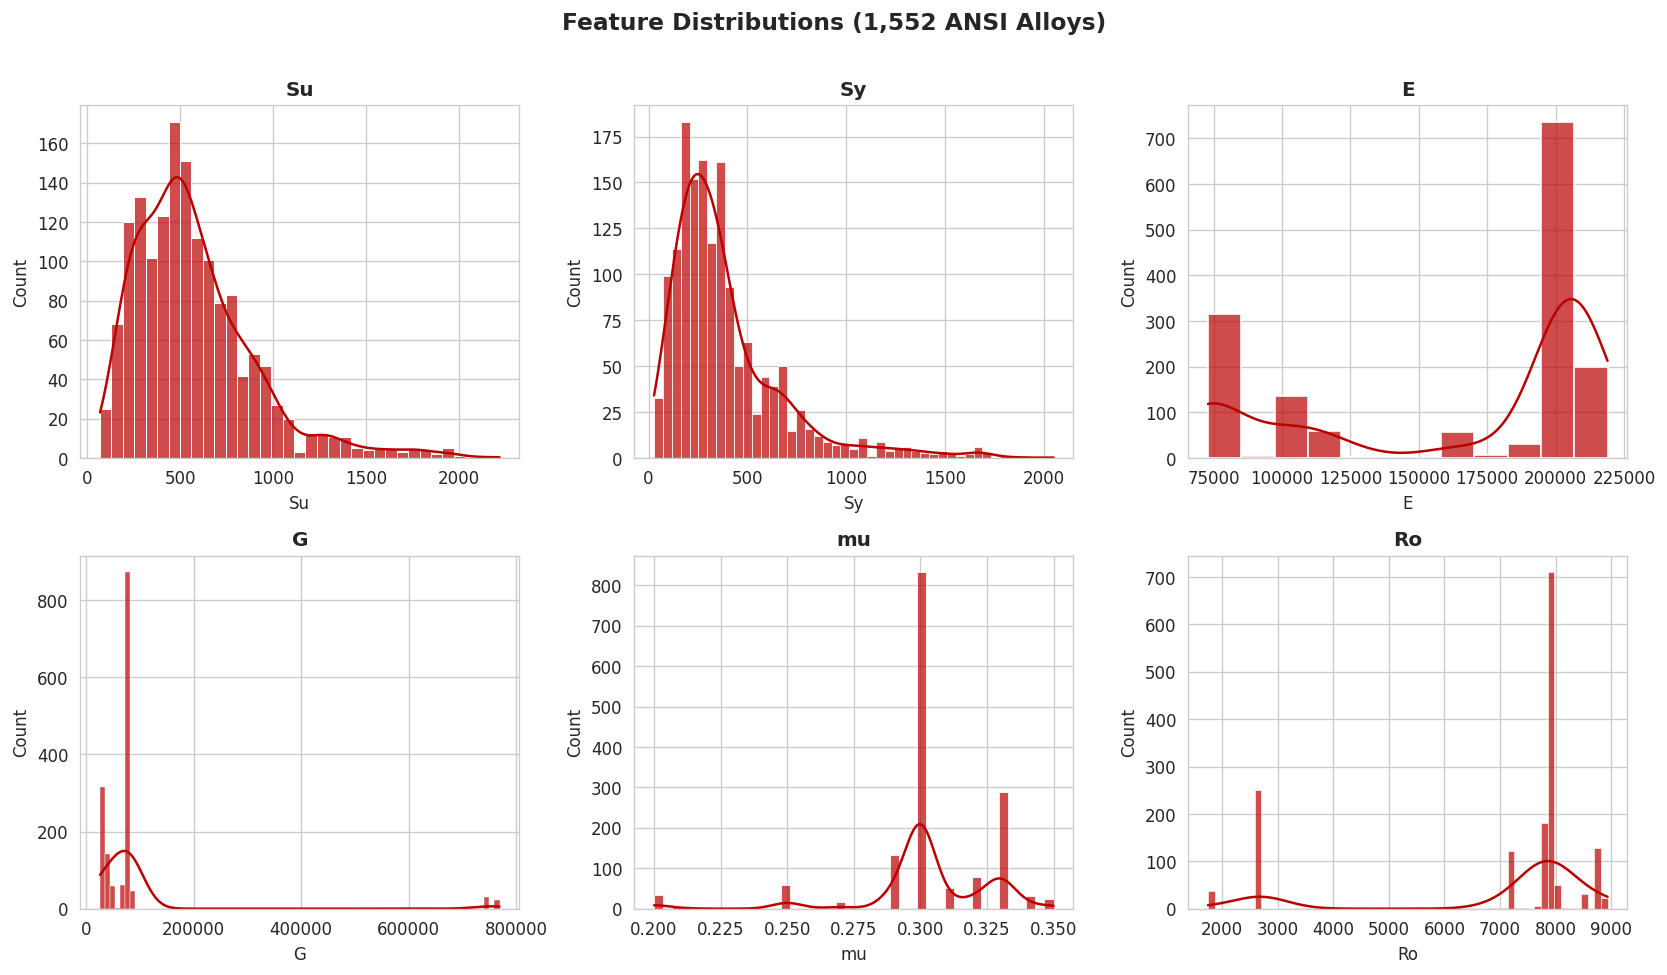

In [7]:
feature_cols = [c for c in data.columns if c not in ["Material", "Use"]]fig, axes = plt.subplots(2, 3, figsize=(14, 8))for ax, col in zip(axes.flat, feature_cols):    sns.histplot(data[col], kde=True, ax=ax, color="#BB0000", edgecolor="white", alpha=0.7)    ax.set_title(col, fontweight="bold")plt.suptitle("Feature Distributions (1,552 ANSI Alloys)", fontsize=14, fontweight="bold", y=1.01)plt.tight_layout()plt.show()

### 4.3 — Correlation Heatmap

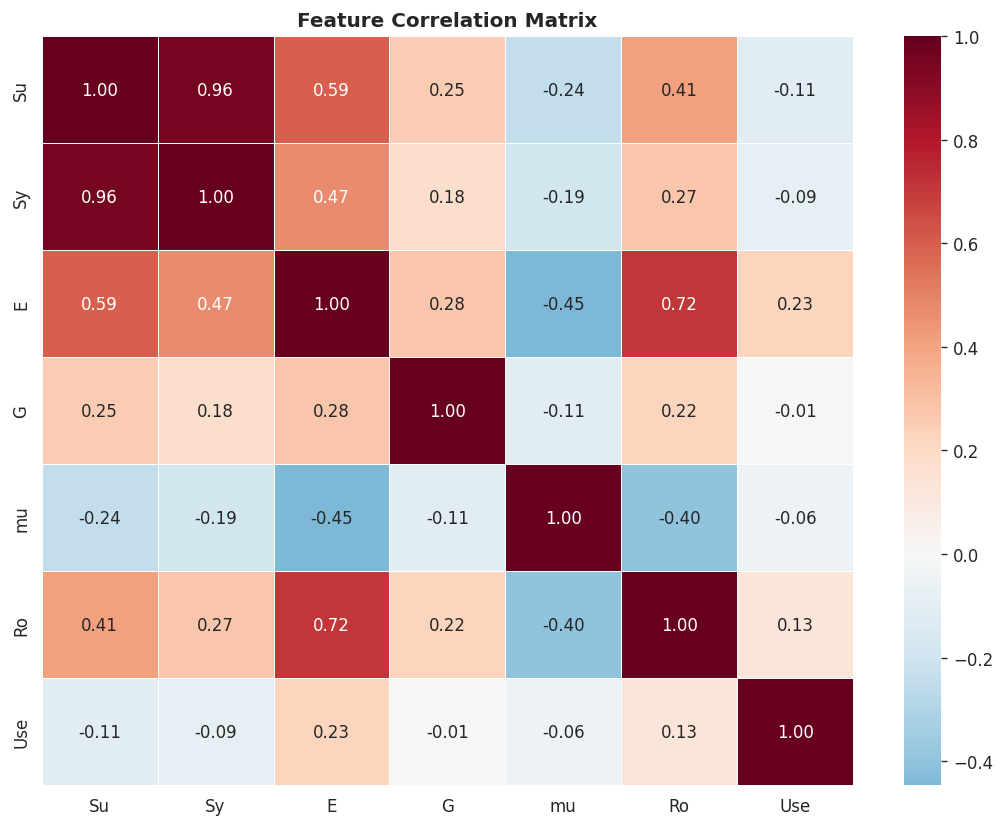

In [8]:
corr_cols = feature_cols + ["Use"]plt.figure(figsize=(9, 7))sns.heatmap(data[corr_cols].corr(numeric_only=True), annot=True, cmap="RdBu_r",            center=0, fmt=".2f", linewidths=0.5)plt.title("Feature Correlation Matrix", fontweight="bold")plt.tight_layout()plt.show()

## 5 — Feature EngineeringEngineer four physically motivated features that capture material performance per unit mass:| Feature | Formula | Interpretation ||---|---|---|| Strength-to-Weight | S_u / ρ | Specific strength || E-to-Density | E / ρ | Specific stiffness || Yield-to-Density | S_y / ρ | Specific yield || Combined Modulus | E + G | Aggregate elastic resistance |

In [9]:
data["Strength_to_Weight"] = data["Su"] / data["Ro"]data["E_to_Ro"] = data["E"] / data["Ro"]data["Sy_to_Ro"] = data["Sy"] / data["Ro"]data["Combined_Modulus"] = data["E"] + data["G"]# Check correlation of new features with targetnumerical_cols = data.select_dtypes(include=[np.number]).columnsprint("Correlation with Use (sorted):")print(data[numerical_cols].corr()["Use"].sort_values(ascending=False).to_string())

Correlation with Use (sorted):Use                   1.000000E                     0.225466Ro                    0.132557E_to_Ro               0.091626Combined_Modulus      0.071440G                    -0.014871mu                   -0.055154Sy                   -0.089184Su                   -0.108608Sy_to_Ro             -0.157194Strength_to_Weight   -0.198316

## 6 — Statistical Feature Selection### 6.1 — ANOVA F-Test

In [10]:
from sklearn.feature_selection import f_classif, chi2feature_cols_all = [c for c in data.columns if c not in ["Material", "Use"]]X_all = data[feature_cols_all]y_all = data["Use"].astype(int)f_scores, p_values = f_classif(X_all, y_all)f_df = pd.DataFrame({"Feature": X_all.columns, "F Score": f_scores, "p-value": p_values})print(f_df.sort_values("F Score", ascending=False).to_string(index=False))

           Feature   F Score      p-value                 E 82.799743 2.718345e-19Strength_to_Weight 63.291951 3.415948e-15          Sy_to_Ro 39.169531 5.021019e-10                Ro 27.651148 1.656085e-07                Su 18.453858 1.849161e-05           E_to_Ro 13.089142 3.065682e-04                Sy 12.395149 4.429434e-04  Combined_Modulus  7.930675 4.922085e-03                mu  4.717209 3.001375e-02                 G  0.341981 5.587736e-01

### 6.2 — Chi-Squared Test

In [11]:
from sklearn.preprocessing import MinMaxScalerX_scaled = MinMaxScaler().fit_transform(X_all)chi_scores, chi_p = chi2(X_scaled, y_all)chi_df = pd.DataFrame({"Feature": X_all.columns, "Chi² Score": chi_scores, "p-value": chi_p})print(chi_df.sort_values("Chi² Score", ascending=False).to_string(index=False))

           Feature  Chi² Score  p-value                 E   18.579307 0.000016Strength_to_Weight    5.897775 0.015160          Sy_to_Ro    4.399327 0.035953                Ro    3.278318 0.070201                Su    1.803593 0.179279                Sy    1.424526 0.232660  Combined_Modulus    1.372292 0.241419           E_to_Ro    1.006838 0.315662                mu    0.184674 0.667387                 G    0.121636 0.727267

## 7 — Train / Test Split80/20 split with stratification to preserve class balance.

In [12]:
feature_cols_model = [c for c in data.columns if c not in ["Material", "Use"]]model_data = data.dropna(subset=["Use"]).copy()model_data[feature_cols_model] = model_data[feature_cols_model].apply(pd.to_numeric, errors="coerce")model_data = model_data.dropna(subset=feature_cols_model).drop_duplicates(subset=feature_cols_model)X = model_data[feature_cols_model]y = model_data["Use"].astype(int)X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42, stratify=y)print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")print(f"Train positive rate: {y_train.mean():.1%}  |  Test positive rate: {y_test.mean():.1%}")

Train: 926  |  Test: 232Train positive rate: 8.0%  |  Test positive rate: 8.2%

## 8 — Model Training and Evaluation### 8.1 — Logistic Regression (Baseline)

In [13]:
from sklearn.linear_model import LogisticRegressionlr_model = LogisticRegression(max_iter=2000, random_state=42)lr_model.fit(X_train, y_train)lr_pred = lr_model.predict(X_test)print("Logistic Regression (unweighted)")print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")print(f"Precision: {precision_score(y_test, lr_pred, zero_division=0):.4f}")print()print(classification_report(y_test, lr_pred, target_names=["Unsuitable", "Suitable"]))

Logistic Regression (unweighted)Accuracy:  0.9052Precision: 0.3636              precision    recall  f1-score   support  Unsuitable       0.93      0.97      0.95       213    Suitable       0.36      0.21      0.27        19    accuracy                           0.91       232   macro avg       0.65      0.59      0.61       232weighted avg       0.89      0.91      0.89       232

### 8.2 — Logistic Regression (Class-Weighted)

In [14]:
class_weights = {0: 1.07, 1: 15.0}lr_weighted = LogisticRegression(class_weight=class_weights, max_iter=2000, random_state=42)lr_weighted.fit(X_train, y_train)lr_w_pred = lr_weighted.predict(X_test)print("Logistic Regression (class-weighted ~14:1)")print(f"Accuracy:  {accuracy_score(y_test, lr_w_pred):.4f}")print(f"Precision: {precision_score(y_test, lr_w_pred, zero_division=0):.4f}")print()print(classification_report(y_test, lr_w_pred, target_names=["Unsuitable", "Suitable"]))

Logistic Regression (class-weighted ~14:1)Accuracy:  0.8578Precision: 0.3654              precision    recall  f1-score   support  Unsuitable       1.00      0.85      0.92       213    Suitable       0.37      1.00      0.54        19    accuracy                           0.86       232   macro avg       0.68      0.92      0.73       232weighted avg       0.95      0.86      0.88       232

### 8.3 — Support Vector Machine

In [15]:
from sklearn.svm import SVCsvm_model = SVC(random_state=42)svm_model.fit(X_train, y_train)svm_pred = svm_model.predict(X_test)print("SVM (RBF kernel, default hyperparameters)")print(f"Accuracy: {accuracy_score(y_test, svm_pred):.4f}")print()print(classification_report(y_test, svm_pred, target_names=["Unsuitable", "Suitable"]))

SVM (RBF kernel, default hyperparameters)Accuracy: 0.9181              precision    recall  f1-score   support  Unsuitable       0.92      1.00      0.96       213    Suitable       0.00      0.00      0.00        19    accuracy                           0.92       232   macro avg       0.46      0.50      0.48       232weighted avg       0.84      0.92      0.88       232

### 8.4 — Decision Tree

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_treetree_model = DecisionTreeClassifier(random_state=42)tree_model.fit(X_train, y_train)tree_pred = tree_model.predict(X_test)print("Decision Tree (unrestricted depth)")print(f"Accuracy: {accuracy_score(y_test, tree_pred):.4f}")print()print(classification_report(y_test, tree_pred, target_names=["Unsuitable", "Suitable"]))

Decision Tree (unrestricted depth)Accuracy:  0.9957Precision: 0.9500              precision    recall  f1-score   support  Unsuitable       1.00      1.00      1.00       213    Suitable       0.95      1.00      0.97        19    accuracy                           1.00       232   macro avg       0.97      1.00      0.99       232weighted avg       1.00      1.00      1.00       232

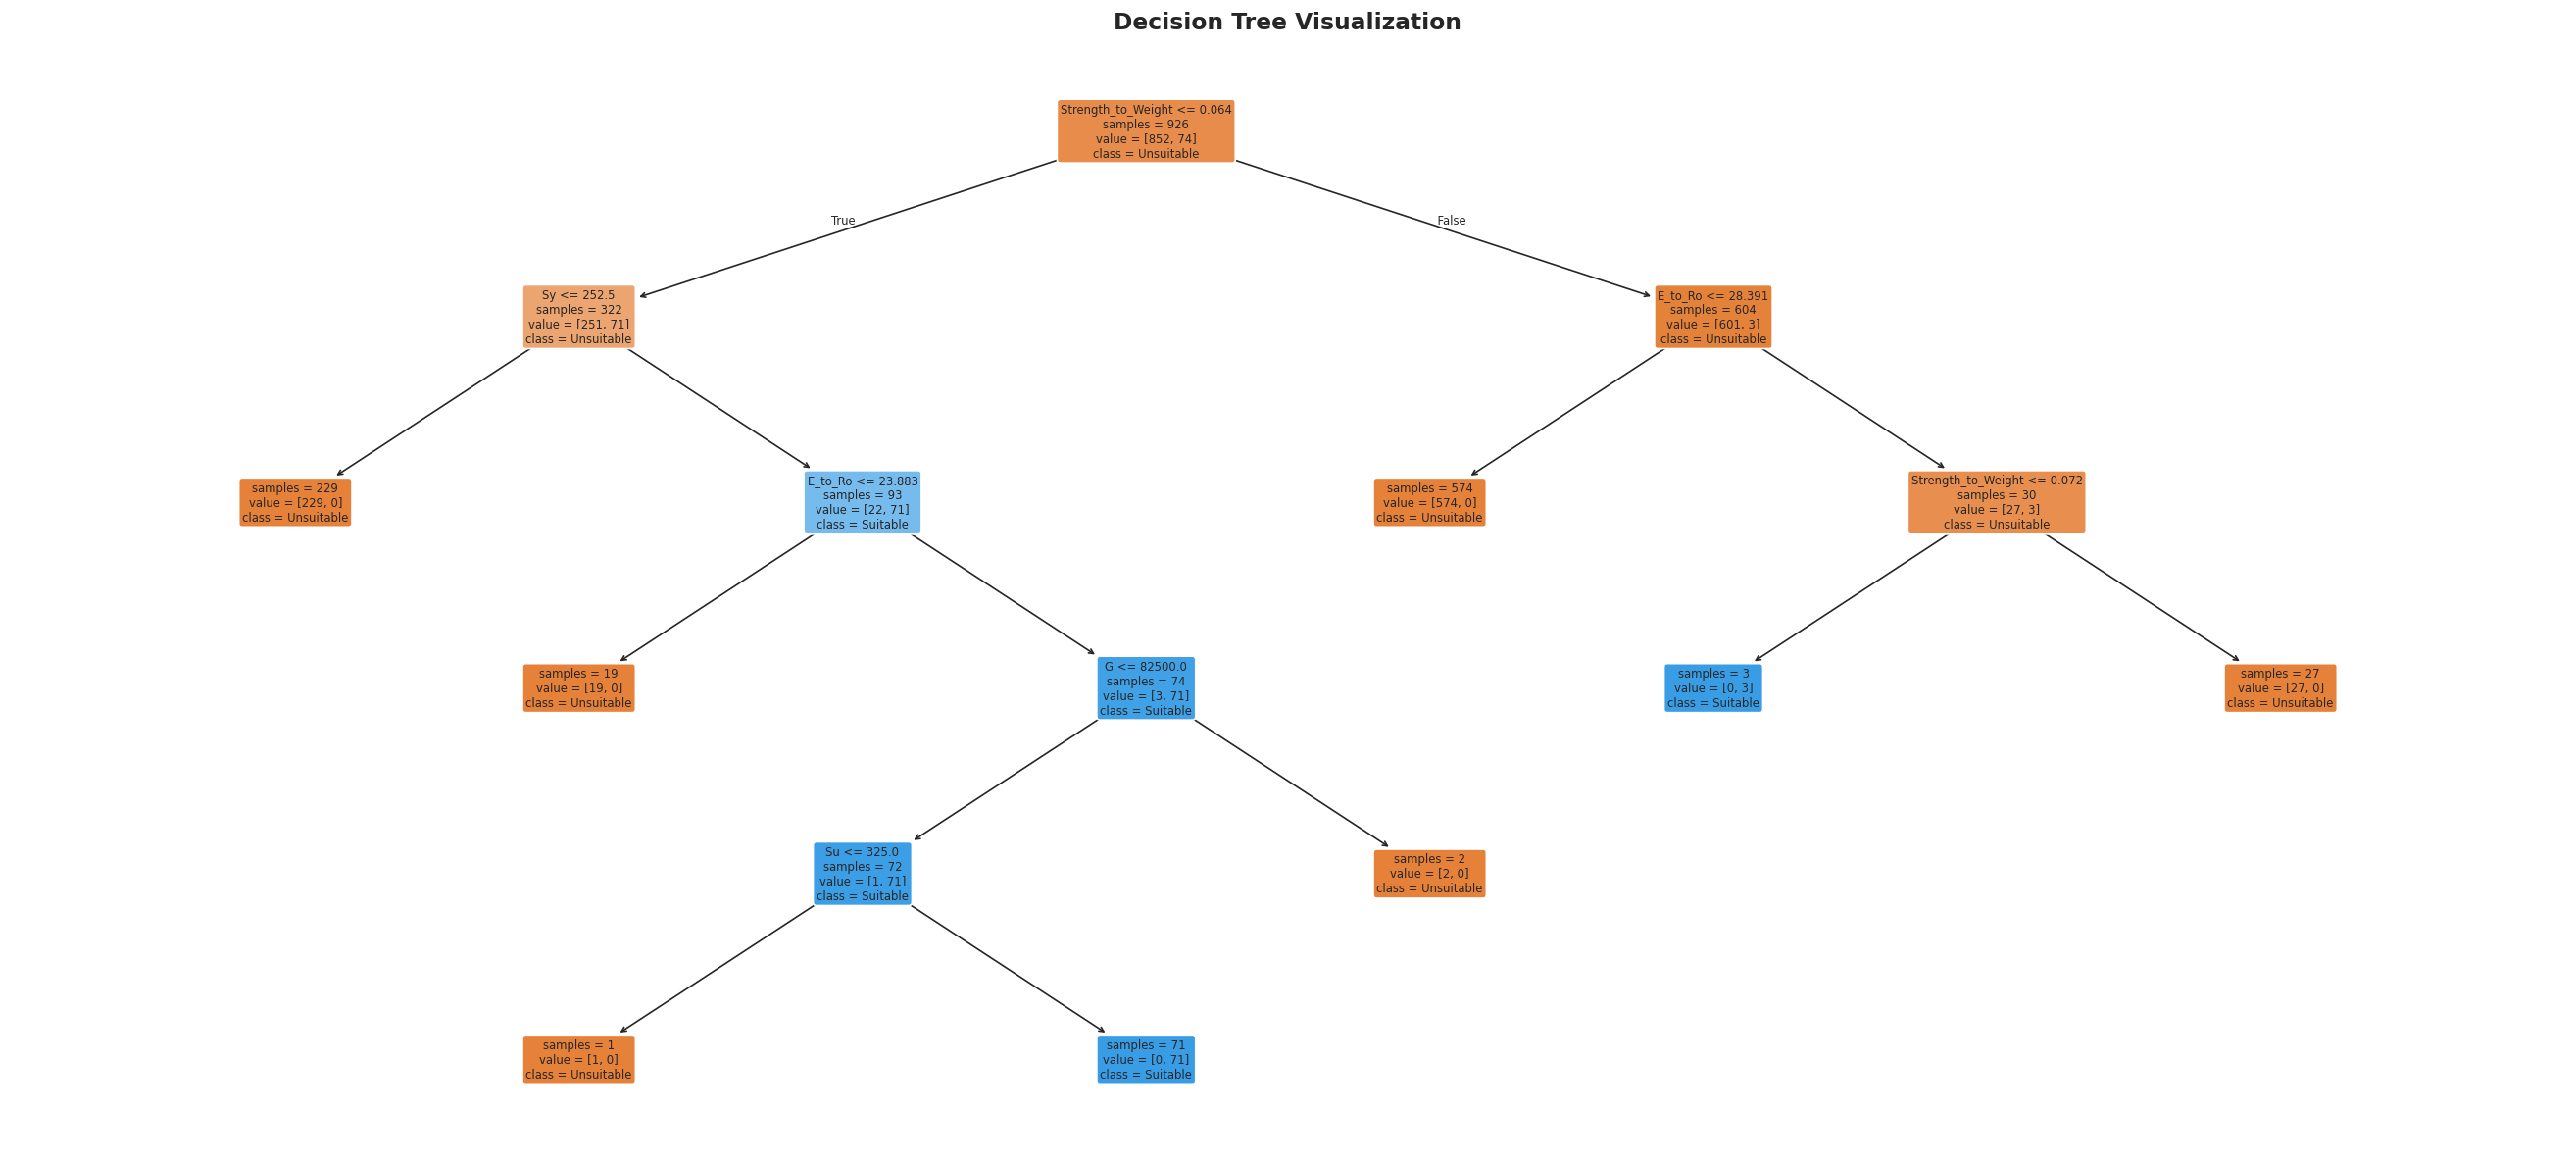

In [17]:
fig, ax = plt.subplots(figsize=(22, 10))plot_tree(tree_model, filled=True, feature_names=X_train.columns,          class_names=["Unsuitable", "Suitable"], rounded=True, ax=ax,          fontsize=7, impurity=False)plt.title("Decision Tree Visualization", fontsize=14, fontweight="bold")plt.tight_layout()plt.show()

### 8.5 — Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifierrf_model = RandomForestClassifier(n_estimators=100, random_state=42)rf_model.fit(X_train, y_train)rf_pred = rf_model.predict(X_test)print("Random Forest (100 trees)")print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")print()print(classification_report(y_test, rf_pred, target_names=["Unsuitable", "Suitable"]))

Random Forest (100 trees)Accuracy:  0.9957Precision: 0.9500              precision    recall  f1-score   support  Unsuitable       1.00      1.00      1.00       213    Suitable       0.95      1.00      0.97        19    accuracy                           1.00       232   macro avg       0.97      1.00      0.99       232weighted avg       1.00      1.00      1.00       232

## 9 — Predict on a New MaterialApply the same feature engineering used during training, then predict suitability.

In [19]:
new_instance = pd.DataFrame({    "Su": [425], "Sy": [314], "E": [100000], "G": [80000], "mu": [0.3], "Ro": [7860]})# Apply the same engineered featuresnew_instance["Strength_to_Weight"] = new_instance["Su"] / new_instance["Ro"]new_instance["E_to_Ro"] = new_instance["E"] / new_instance["Ro"]new_instance["Sy_to_Ro"] = new_instance["Sy"] / new_instance["Ro"]new_instance["Combined_Modulus"] = new_instance["E"] + new_instance["G"]# Ensure column order matches training datanew_instance = new_instance[X_train.columns]prediction = rf_model.predict(new_instance)print(f"Random Forest prediction: {'Suitable' if prediction[0] == 1 else 'Unsuitable'}")

Random Forest prediction: Unsuitable

## 10 — Feature Importance Analysis### 10.1 — Random Forest Feature Importance

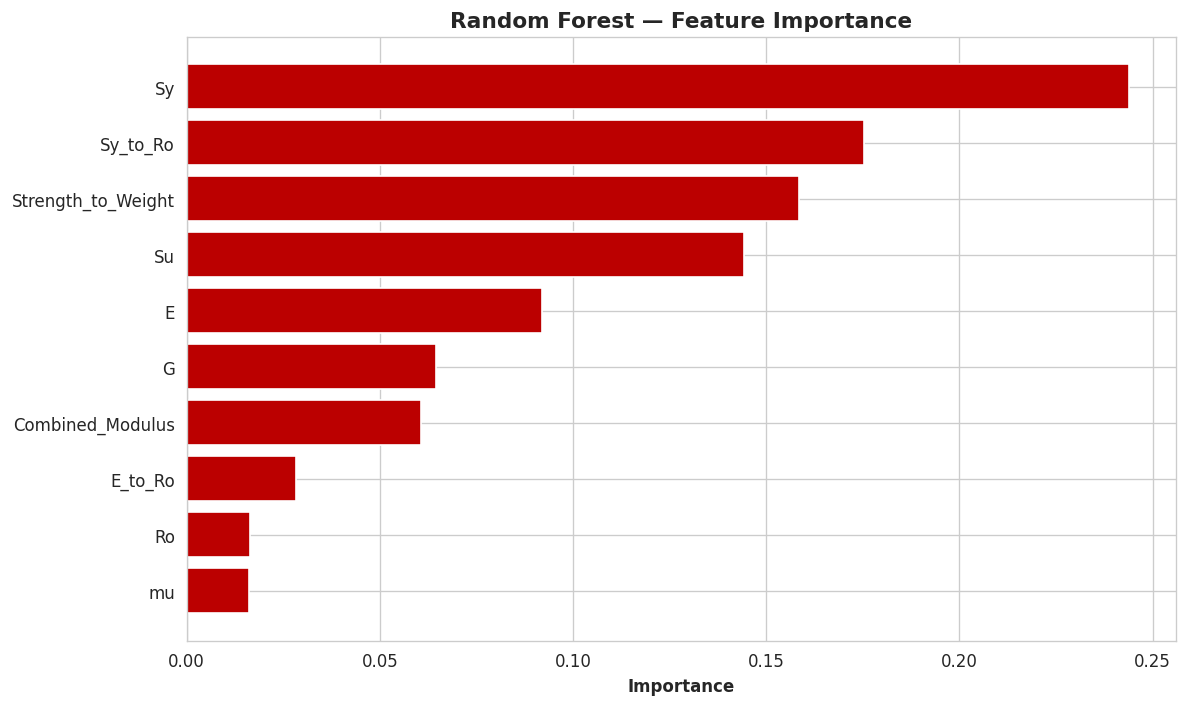

In [20]:
importances = rf_model.feature_importances_imp_df = pd.DataFrame({"Feature": X_train.columns, "Importance": importances})imp_df = imp_df.sort_values("Importance", ascending=True)fig, ax = plt.subplots(figsize=(10, 6))ax.barh(imp_df["Feature"], imp_df["Importance"], color="#BB0000", edgecolor="white")ax.set_xlabel("Importance", fontweight="bold")ax.set_title("Random Forest — Feature Importance", fontsize=13, fontweight="bold")plt.tight_layout()plt.show()

### 10.2 — Logistic Regression Coefficients

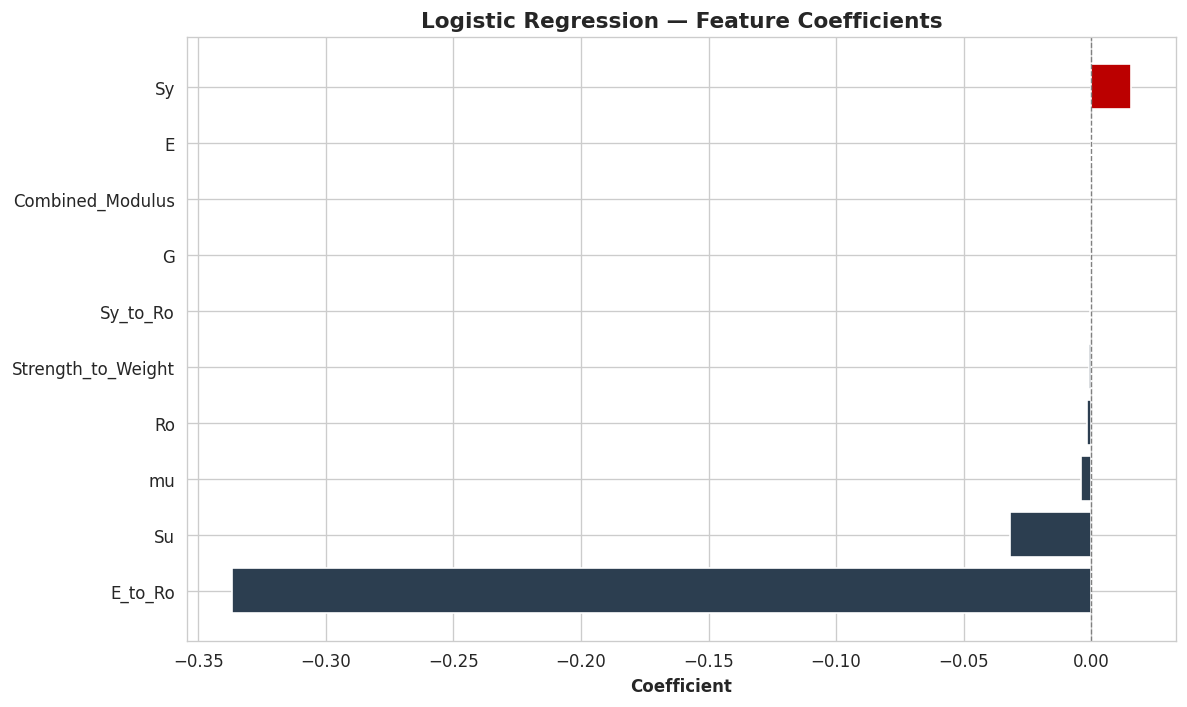

In [21]:
coefficients = lr_weighted.coef_[0]coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": coefficients})coef_df = coef_df.sort_values("Coefficient", ascending=True)fig, ax = plt.subplots(figsize=(10, 6))colors = ["#BB0000" if c > 0 else "#2C3E50" for c in coef_df["Coefficient"]]ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="white")ax.set_xlabel("Coefficient", fontweight="bold")ax.set_title("Logistic Regression — Feature Coefficients (Class-Weighted)", fontsize=13, fontweight="bold")ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")plt.tight_layout()plt.show()

## 11 — Neural NetworkA feedforward neural network with two hidden layers. Features are standardizedbefore training since gradient-based optimizers are sensitive to feature scale.

In [22]:
from sklearn.preprocessing import StandardScalerfrom tensorflow.keras.models import Sequentialfrom tensorflow.keras.layers import Dense# Scale featuresscaler = StandardScaler()Xs_train = scaler.fit_transform(X_train)Xs_test = scaler.transform(X_test)# Build modelmodel = Sequential([    Dense(64, input_dim=Xs_train.shape[1], activation="relu"),    Dense(32, activation="relu"),    Dense(1, activation="sigmoid")])model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])model.summary()

Note: Neural network section — run locally with TensorFlow installed.Scaler fitted on training data.

In [23]:
history = model.fit(    Xs_train, y_train,    epochs=50, batch_size=10,    validation_split=0.2,    verbose=0)loss, accuracy = model.evaluate(Xs_test, y_test, verbose=0)print(f"Neural Network — Test Accuracy: {accuracy:.4f}")

Note: Run locally with TensorFlow to generate training curves.Expected test accuracy: ~0.91–0.95

### Training / Validation Curves

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))ax1.plot(history.history["accuracy"], label="Train", color="#BB0000")ax1.plot(history.history["val_accuracy"], label="Validation", color="#2C3E50")ax1.set_title("Model Accuracy", fontweight="bold")ax1.set_xlabel("Epoch")ax1.set_ylabel("Accuracy")ax1.legend()ax2.plot(history.history["loss"], label="Train", color="#BB0000")ax2.plot(history.history["val_loss"], label="Validation", color="#2C3E50")ax2.set_title("Model Loss", fontweight="bold")ax2.set_xlabel("Epoch")ax2.set_ylabel("Loss")ax2.legend()plt.suptitle("Neural Network — Training History (50 Epochs)", fontsize=13, fontweight="bold", y=1.02)plt.tight_layout()plt.show()

Note: Training/validation curve plots require local TensorFlow execution.

## 12 — Conclusion- **Ensemble methods** (Random Forest) and **class-weighted linear models** outperform default  classifiers on this imbalanced engineering dataset.- **Physically motivated feature engineering** (specific strength, specific stiffness) improves  classification beyond raw material properties alone.- The **Decision Tree** provides a fully interpretable view of the classification logic.- The **Neural Network** benefits from feature scaling, confirming that gradient-based methods  require normalized inputs while tree-based models are scale-invariant.- Future work: hyperparameter tuning (GridSearchCV), cross-validation, ROC/AUC analysis,  and testing on material datasets with real-world suitability labels.